## TypedDict Schema

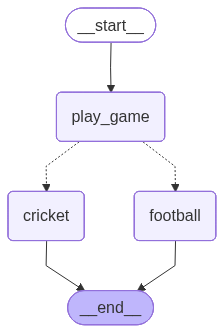

In [1]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from typing_extensions import  TypedDict
from typing import Literal
import random

# create class structure
class State(TypedDict):
    name:str
    game: Literal["cricket", "football"]


# create node functions
def play_game(state:State):
    print(f"play_game node executed")
    return {"name": state['name'] + " want to play "}

# game node functions
def cricket(state:State):
    print(f"cricket node executed")
    return {"name": state['name'] + "cricket", "game": "cricket"}

def football(state:State):
    print(f"football node executed")
    return {"name": state['name'] + "football", "game": "football"}

def decide_game(state:State) -> Literal["cricket", 'football']:
    if random.random() > 0.5:
        return 'cricket'
    else:
        return 'football'

# Constructing the graph
graph = StateGraph(State)

graph.add_node("play_game", play_game)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game", decide_game)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

graph_builder = graph.compile()

# Displaying the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [2]:
graph_builder.invoke({"name":"Abhishek"})

play_game node executed
football node executed


{'name': 'Abhishek want to play football', 'game': 'football'}

## DataClass Schema

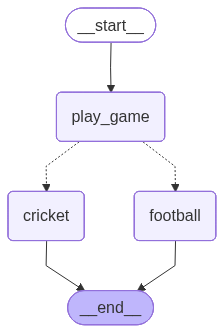

In [3]:
from dataclasses import dataclass
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from typing_extensions import  TypedDict
from typing import Literal
import random

# create class structure
@dataclass
class DataClassState():
    name:str
    game: Literal["cricket", "football"]


# create node functions
def play_game(state:DataClassState):
    print(f"play_game node executed")
    return {"name": state.name + " want to play "}

# game node functions
def cricket(state:DataClassState):
    print(f"cricket node executed")
    return {"name": state.name + "cricket", "game": "cricket"}

def football(state:DataClassState):
    print(f"football node executed")
    return {"name": state.name + "football", "game": "football"}

def decide_game(state:DataClassState) -> Literal["cricket", 'football']:
    if random.random() > 0.5:
        return 'cricket'
    else:
        return 'football'

# Constructing the graph
graph = StateGraph(DataClassState)

graph.add_node("play_game", play_game)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game", decide_game)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

graph_builder = graph.compile()

# Displaying the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [4]:
graph_builder.invoke(DataClassState(name="abhishek", game=None))

play_game node executed
football node executed


{'name': 'abhishek want to play football', 'game': 'football'}

## Pydantic Schema

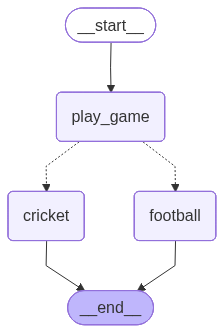

In [9]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Literal, Optional
import random

# create class structure
class PydanticClass(BaseModel):
    name:str
    game: Optional[Literal["cricket", "football"]] = None


# create node functions
def play_game(state:PydanticClass):
    print(f"play_game node executed")
    return {"name": state.name + " want to play "}

# game node functions
def cricket(state:PydanticClass):
    print(f"cricket node executed")
    return {"name": state.name + "cricket", "game": "cricket"}

def football(state:PydanticClass):
    print(f"football node executed")
    return {"name": state.name + "football", "game": "football"}

def decide_game(state:PydanticClass) -> Literal["cricket", 'football']:
    if random.random() > 0.5:
        return 'cricket'
    else:
        return 'football'

# Constructing the graph
graph = StateGraph(PydanticClass)

graph.add_node("play_game", play_game)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

graph.add_edge(START, "play_game")
graph.add_conditional_edges("play_game", decide_game)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

graph_builder = graph.compile()

# Displaying the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [12]:
graph_builder.invoke({"name":"Abhishek"})

play_game node executed
football node executed


{'name': 'Abhishek want to play football', 'game': 'football'}